In [40]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

#data splits
TRAIN_SPLIT = 70
VAL_SPLIT = 15
TEST_SPLIT = 15

FEATURES = ["accel_x", "accel_y", "accel_z"]
LABELS = [
    "still",
    "shake",
    "tilt forward",
    "tilt backward",
    "tilt left",
    "tilt right",
]

LABEL_TO_ID = {name: i for i, name in enumerate(LABELS)}
ID_TO_LABEL = {i: name for name, i in LABEL_TO_ID.items()}

In [41]:
#Load CSV into (n_samples, 50, 3) arrays
TIMESTEPS = 50
df = pd.read_csv("data.csv")

samples = []
labels = []

for sample_id, group in df.groupby("sample_id", sort=False):
    group = group.sort_values("timestamp")
    if len(group) != TIMESTEPS:
        raise ValueError(f"{sample_id} has {len(group)} rows, expected {TIMESTEPS}")

    samples.append(group[FEATURES].to_numpy(dtype=np.float32))
    labels.append(group["label"].iloc[0])

X = np.stack(samples)
y = np.array([LABEL_TO_ID[label] for label in labels], dtype=np.int32)

print(f"X shape: {X.shape}")  # (600, 50, 3)
print(f"y shape: {y.shape}")  # (600,)

X shape: (600, 50, 3)
y shape: (600,)


In [42]:
def balanced_stratified_split(X, y):
    """70/15/15 split per class; shuffle samples within class, keep timesteps ordered."""
    rng = np.random.default_rng(42)

    train_idx, val_idx, test_idx = [], [], []

    for class_id in range(len(LABELS)):
        class_indices = np.where(y == class_id)[0]
        if len(class_indices) != TRAIN_SPLIT + VAL_SPLIT + TEST_SPLIT:
            raise ValueError(
                f"class {ID_TO_LABEL[class_id]} has {len(class_indices)} samples, "
                f"expected {TRAIN_SPLIT + VAL_SPLIT + TEST_SPLIT}"
            )

        rng.shuffle(class_indices)
        train_idx.extend(class_indices[:TRAIN_SPLIT])
        val_idx.extend(class_indices[TRAIN_SPLIT : TRAIN_SPLIT + VAL_SPLIT])
        test_idx.extend(class_indices[TRAIN_SPLIT + VAL_SPLIT :])

    def take(indices):
        indices = np.array(indices)
        return X[indices], y[indices]

    return take(train_idx), take(val_idx), take(test_idx)


def to_tensors(X, y):
    return tf.constant(X, dtype=tf.float32), tf.constant(y, dtype=tf.int32)


def split_counts(y, name):
    unique, counts = np.unique(y, return_counts=True)
    print(f"{name}: {len(y)} samples")
    for label_id, count in zip(unique, counts):
        print(f"  {ID_TO_LABEL[label_id]}: {count}")

In [43]:
(X_train, y_train), (X_val, y_val), (X_test, y_test) = balanced_stratified_split(X, y)

X_train, y_train = to_tensors(X_train, y_train)
X_val, y_val = to_tensors(X_val, y_val)
X_test, y_test = to_tensors(X_test, y_test)

split_counts(y_train.numpy(), "train")
split_counts(y_val.numpy(), "val")
split_counts(y_test.numpy(), "test")

train: 420 samples
  still: 70
  shake: 70
  tilt forward: 70
  tilt backward: 70
  tilt left: 70
  tilt right: 70
val: 90 samples
  still: 15
  shake: 15
  tilt forward: 15
  tilt backward: 15
  tilt left: 15
  tilt right: 15
test: 90 samples
  still: 15
  shake: 15
  tilt forward: 15
  tilt backward: 15
  tilt left: 15
  tilt right: 15


In [44]:
model = tf.keras.Sequential([
    tf.keras.layers.Input((150,)),  # 50*3=150
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(6, activation='softmax')
])

model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 32)             │         4,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,462 (21.34 KB)

 Trainable params: 5,462 (21.34 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9976 - loss: 0.0178 - val_accuracy: 0.9889 - val_loss: 0.0942
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9976 - loss: 0.0178 - val_accuracy: 0.9889 - val_loss: 0.0953
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9976 - loss: 0.0178 - val_accuracy: 0.9889 - val_loss: 0.0976
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9976 - loss: 0.0171 - val_accuracy: 0.9889 - val_loss: 0.0952
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9976 - loss: 0.0174 - val_accuracy: 0.9889 - val_loss: 0.0979
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9976 - loss: 0.0170 - val_accuracy: 0.9889 - val_loss: 0.0980
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9976 - loss: 0.0176 - val_accuracy: 0.9889 - val_loss: 0.0967
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9976 - loss: 0.0161 - val_accuracy: 0.9889 - val_loss:

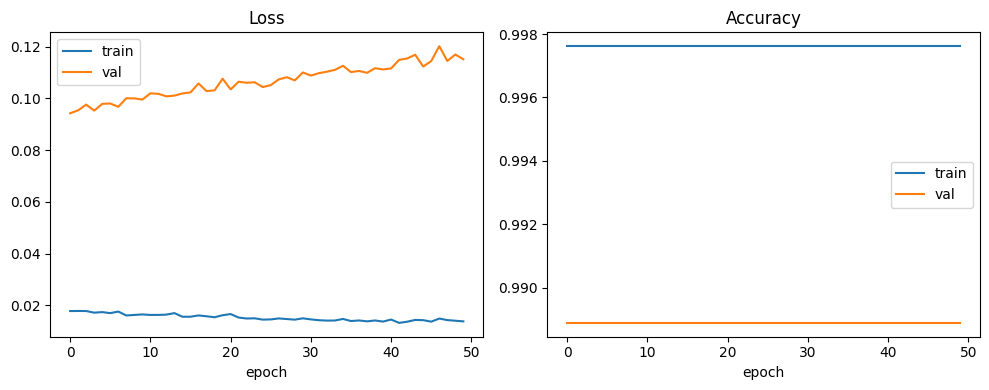

train — loss: 0.0130, accuracy: 0.9976
val   — loss: 0.1151, accuracy: 0.9889
test  — loss: 0.1519, accuracy: 0.9556


In [46]:
X_train_flat = X_train.numpy().reshape(-1, 150)
X_test_flat  = X_test.numpy().reshape(-1, 150)
X_val_flat   = X_val.numpy().reshape(-1, 150)

history = model.fit(X_train_flat, y_train, validation_data=(X_val_flat, y_val), epochs=50, batch_size=32)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("epoch")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="train")
axes[1].plot(history.history["val_accuracy"], label="val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

train_loss, train_acc = model.evaluate(X_train_flat, y_train, verbose=0)
val_loss, val_acc = model.evaluate(X_val_flat, y_val, verbose=0)
test_loss, test_acc = model.evaluate(X_test_flat, y_test, verbose=0)

print(f"train — loss: {train_loss:.4f}, accuracy: {train_acc:.4f}")
print(f"val   — loss: {val_loss:.4f}, accuracy: {val_acc:.4f}")
print(f"test  — loss: {test_loss:.4f}, accuracy: {test_acc:.4f}")

In [55]:
FLOAT_MODEL_TFLITE = "model_float.tflite"
INT8_MODEL_TFLITE = "model_int82.tflite"

# Float conversion — convert directly from the Keras model, skip export
float_converter = tf.lite.TFLiteConverter.from_keras_model(model)
float_tflite_model = float_converter.convert()
open(FLOAT_MODEL_TFLITE, "wb").write(float_tflite_model)
print("Float model is %d bytes" % len(float_tflite_model))

# Int8 quantized conversion
def representative_dataset_gen():
    for i in range(100):
        sample = X_train_flat[i : i + 1].astype(np.float32)
        yield [sample]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8
tflite_model = converter.convert()
open(INT8_MODEL_TFLITE, "wb").write(tflite_model)
print("Int8 model is %d bytes" % len(tflite_model))

# Verify ops
interp = tf.lite.Interpreter(INT8_MODEL_TFLITE)
interp.allocate_tensors()
for op in interp._get_ops_details():
    print(op['op_name'])

Saved artifact at '/tmp/tmpg0dc52tl'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150), dtype=tf.float32, name='keras_tensor_19')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  140401984197968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140401984199312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140401984199120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140401984198544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140401984199888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140401984199504: TensorSpec(shape=(), dtype=tf.resource, name=None)
Float model is 24000 bytes
Saved artifact at '/tmp/tmp55uuud61'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150), dtype=tf.float32, name='keras_tensor_19')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captu

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [53]:
def run_tflite(model_path, X, y):
    interpreter = tf.lite.Interpreter(model_path=model_path)
    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    X_np = np.array(X)
    y_np = np.array(y)
    correct = 0

    for i in range(len(X_np)):
        x = X_np[i : i + 1]

        if input_details[0]["dtype"] == np.int8:
            scale = input_details[0]["quantization_parameters"]["scales"][0]
            zero_point = input_details[0]["quantization_parameters"]["zero_points"][0]
            x = (x / scale + zero_point).astype(np.int8)

        interpreter.set_tensor(input_details[0]["index"], x)
        interpreter.invoke()
        out = interpreter.get_tensor(output_details[0]["index"])

        if output_details[0]["dtype"] == np.int8:
            scale = output_details[0]["quantization_parameters"]["scales"][0]
            zero_point = output_details[0]["quantization_parameters"]["zero_points"][0]
            out = (out.astype(np.float32) - zero_point) * scale

        if np.argmax(out) == y_np[i]:
            correct += 1

    return correct / len(X_np)


for name, X, y in [("train", X_train_flat, y_train), ("val", X_val_flat, y_val), ("test", X_test_flat, y_test)]:
    acc = run_tflite(INT8_MODEL_TFLITE, X, y)
    print(f"INT8 TFLite {name} accuracy: {acc:.4f}")

for name, X, y in [("train", X_train_flat, y_train), ("val", X_val_flat, y_val), ("test", X_test_flat, y_test)]:
    acc = run_tflite(FLOAT_MODEL_TFLITE, X, y)
    print(f"float TFLite {name} accuracy: {acc:.4f}")

INT8 TFLite train accuracy: 0.9976
INT8 TFLite val accuracy: 0.9889
INT8 TFLite test accuracy: 0.9556
float TFLite train accuracy: 0.9976
float TFLite val accuracy: 0.9889
float TFLite test accuracy: 0.9556


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
